# E-commerce Transaction Data Analysis

## Objective
The goal of this analysis is to explore an e-commerce transaction dataset and identify patterns in:
- Transaction amount distribution
- Sales trends over time
- Revenue by product category
- Customer purchasing behavior

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset
Ecommerce Transactions Dataset containing:
- Customer information
- Product categories
- Transaction dates
- Quantity and price

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Loading
First, we import the dataset and inspect its structure to understand the variables and data types.

In [4]:
df = pd.read_csv("Ecommerce_Transactions_Data.csv")
df.head()

,TransactionNo,Date,ProductNo,Product,Price,Quantity,CustomerNo,Country,Category
0,704274,2024-03-06,10010,LED String Lights,10.00,11,13673.0,Netherlands,Lighting & Ambience
1,439989,2024-12-27,10001,Vintage Clock,15.99,8,56712.0,Sweden,Decor Essentials
2,607445,2024-11-16,10008,Notebook Pack,7.50,23,45809.0,Canada,Office & Study
3,784100,2023-06-11,10001,Vintage Clock,15.99,29,98102.0,Switzerland,Decor Essentials
4,973030,2024-04-21,10003,Wooden Picture Frame,9.99,4,26596.0,Belgium,Decor Essentials


In [5]:
df.shape

(500000, 9)

In [6]:
df.columns

Index(['TransactionNo', 'Date', 'ProductNo', 'Product', 'Price', 'Quantity',
       'CustomerNo', 'Country', 'Category'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  500000 non-null  object 
 1   Date           500000 non-null  object 
 2   ProductNo      500000 non-null  int64  
 3   Product        500000 non-null  object 
 4   Price          500000 non-null  float64
 5   Quantity       500000 non-null  int64  
 6   CustomerNo     495038 non-null  float64
 7   Country        500000 non-null  object 
 8   Category       500000 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 34.3+ MB


In [8]:
df.describe()

,ProductNo,Price,Quantity,CustomerNo
count,500000.000000,500000.000000,500000.000000,495038.000000
mean,10005.496916,14.779835,14.583058,55004.411205
std,2.872036,7.213341,10.137969,25998.016638
min,10001.000000,5.000000,-30.000000,10000.000000
25%,10003.000000,9.990000,7.000000,32447.000000
50%,10005.000000,14.000000,15.000000,55000.000000
75%,10008.000000,19.990000,23.000000,77548.000000
max,10010.000000,30.000000,30.000000,99999.000000


## Data Cleaning
Data cleaning is essential to ensure accuracy. The following steps are performed:
- Handling missing values
- Removing invalid quantities
- Converting date columns to datetime format

In [10]:
df.isnull().sum()

TransactionNo       0
Date                0
ProductNo           0
Product             0
Price               0
Quantity            0
CustomerNo       4962
Country             0
Category            0
dtype: int64

CustomerNo contains missing values. Since customer identification is critical for analysis, rows with missing CustomerNo are removed.

In [12]:
df = df.dropna(subset=["CustomerNo"])

In [13]:
df.isnull().sum()

TransactionNo    0
Date             0
ProductNo        0
Product          0
Price            0
Quantity         0
CustomerNo       0
Country          0
Category         0
dtype: int64

In [14]:
df["CustomerNo"] = df["CustomerNo"].astype(int)

In [15]:
df = df[df["Quantity"]>0]

In [16]:
df["Date"] = pd.to_datetime(df["Date"])

In [17]:
df.shape

(480188, 9)

In [18]:
df["Total Amount"] = df["Price"] * df["Quantity"]
df.head()

,TransactionNo,Date,ProductNo,Product,Price,Quantity,CustomerNo,Country,Category,Total Amount
0,704274,2024-03-06,10010,LED String Lights,10.00,11,13673,Netherlands,Lighting & Ambience,110.00
1,439989,2024-12-27,10001,Vintage Clock,15.99,8,56712,Sweden,Decor Essentials,127.92
2,607445,2024-11-16,10008,Notebook Pack,7.50,23,45809,Canada,Office & Study,172.50
3,784100,2023-06-11,10001,Vintage Clock,15.99,29,98102,Switzerland,Decor Essentials,463.71
4,973030,2024-04-21,10003,Wooden Picture Frame,9.99,4,26596,Belgium,Decor Essentials,39.96


Text(0.5, 1.0, 'Outlier Detection in Transaction Amount')

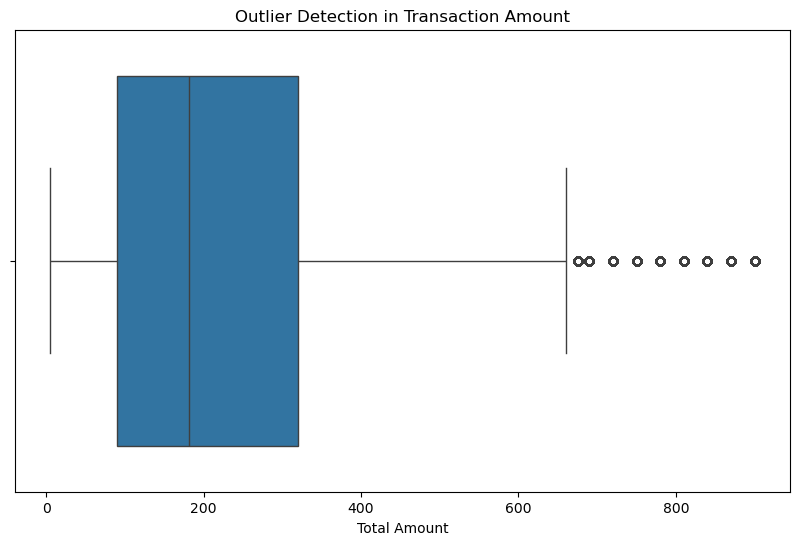

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df["Total Amount"])
plt.title("Outlier Detection in Transaction Amount")

## Distribution of transaction amounts.

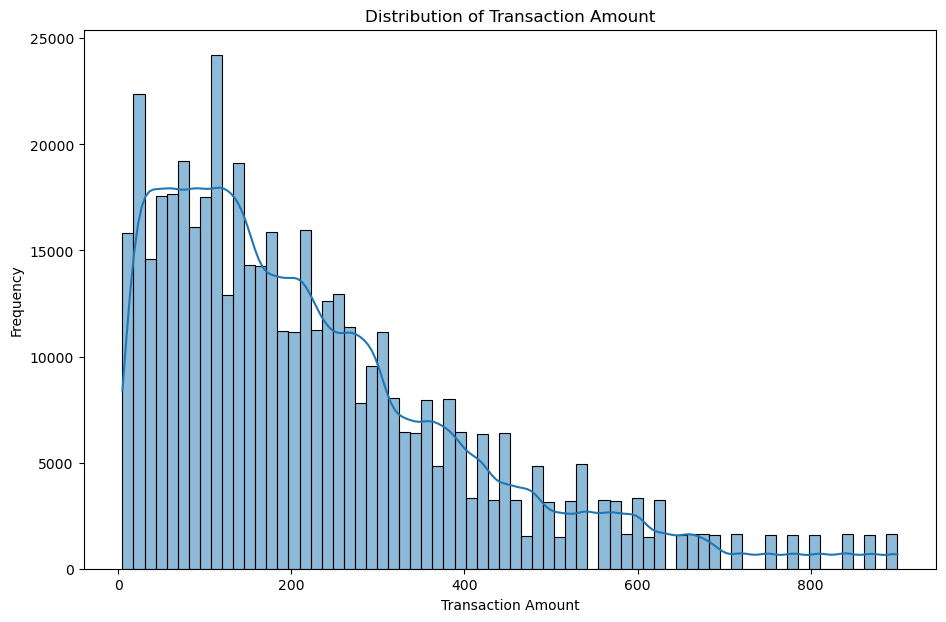

In [21]:
plt.figure(figsize = (11,7))
sns.histplot(df["Total Amount"], bins=70 ,kde =True,)
plt.title("Distribution of Transaction Amount",loc = 'center',)
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

In [22]:
plt.savefig("Transaction_distribution.png")

<Figure size 640x480 with 0 Axes>

## Total transaction amount vary over time.

In [24]:
df['Month'] = df['Date'].dt.to_period('M')

In [25]:
monthly_sales = df.groupby('Month')['Total Amount'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

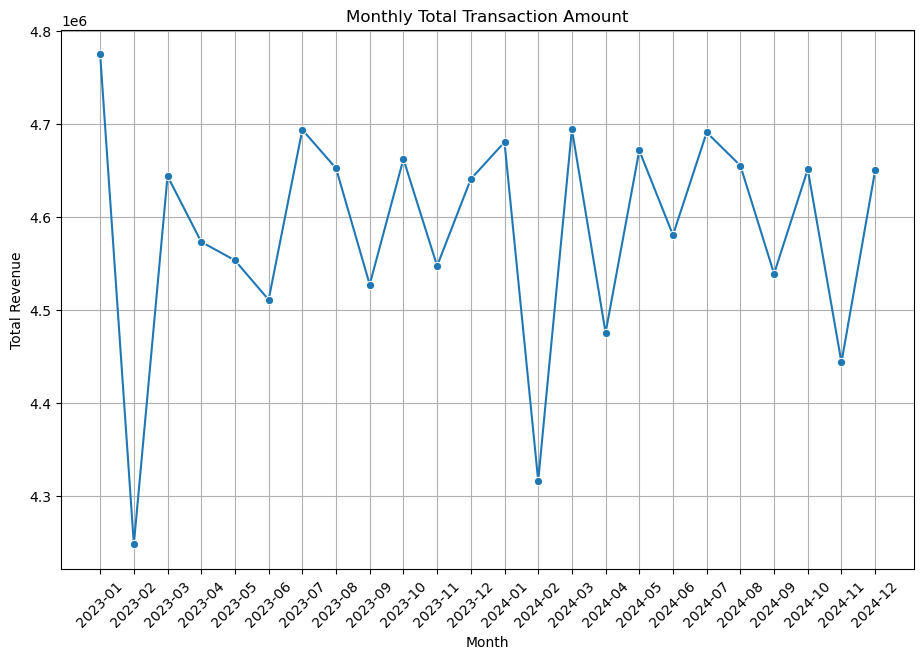

In [26]:
plt.figure(figsize = (11,7))

sns.lineplot(data=monthly_sales, x='Month', y='Total Amount', marker='o')

plt.title("Monthly Total Transaction Amount")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [27]:
plt.savefig("Total_transaction_over_time.png")

<Figure size 640x480 with 0 Axes>

 ## Product categories generate the most revenue.

In [29]:
category_sales = df.groupby('Category')['Total Amount'].sum().sort_values(ascending=False)

In [30]:
category_sales.head()

Category
Home Accents           39194385.00
Decor Essentials       19410620.67
Gifting & Occasions    18607313.19
Lighting & Ambience    16858025.25
Office & Study         16009569.50
Name: Total Amount, dtype: float64

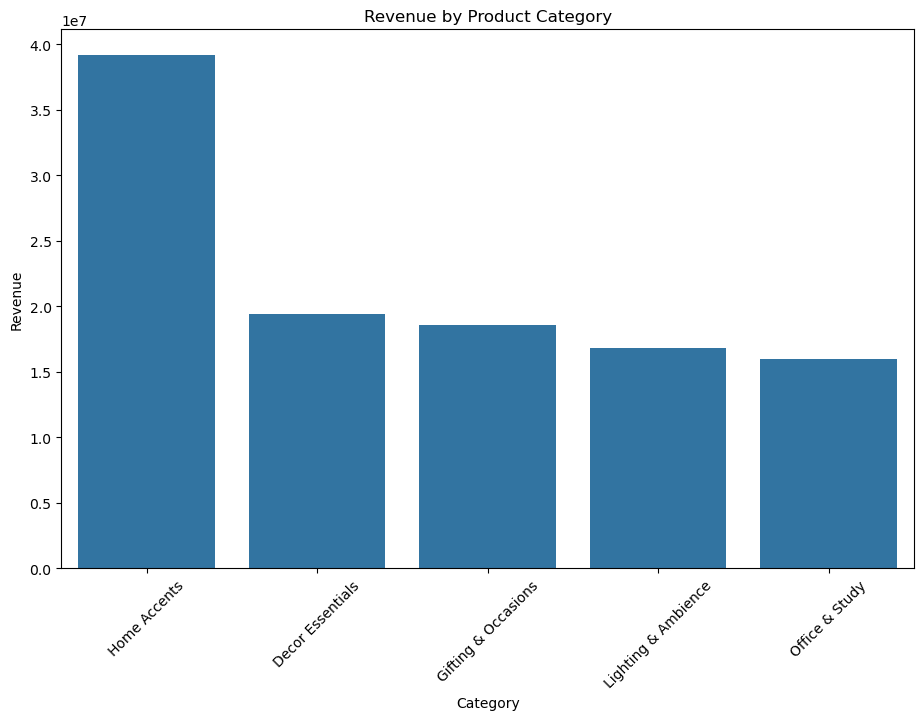

In [31]:
plt.figure(figsize = (11,7))
sns.barplot(x = category_sales.index,y=category_sales.values)
plt.title("Revenue by Product Category")
plt.xticks(rotation = 45)
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

In [32]:
plt.savefig("Revenue_by_product_category.png")

<Figure size 640x480 with 0 Axes>

## Trends or patterns in customer purchasing behaviour.

## Top Countries by Sale

In [35]:
country_sales = df.groupby('Country')['Total Amount'].sum().sort_values(ascending=False).head(10)

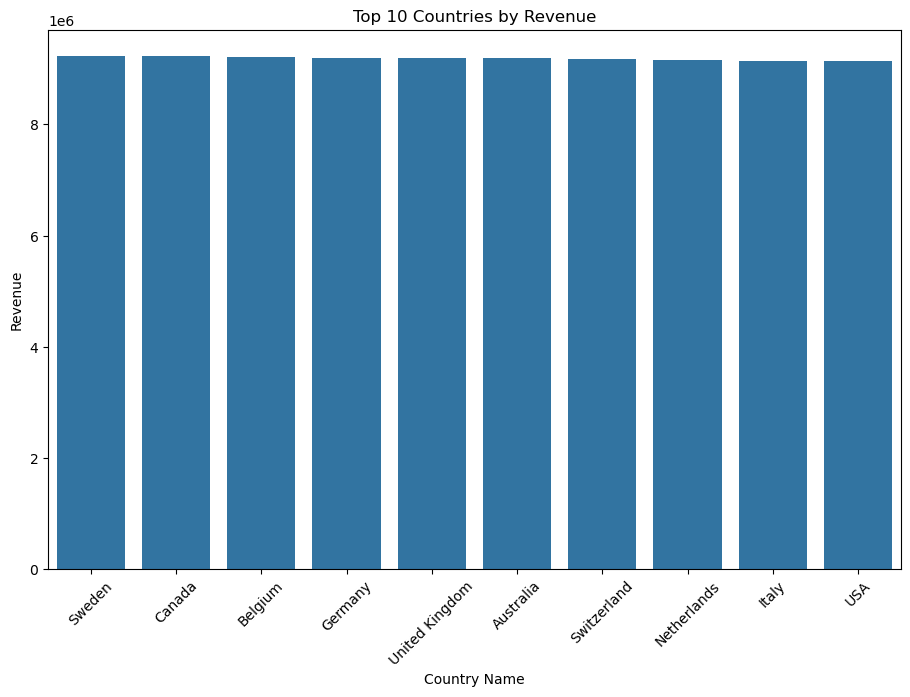

In [36]:
plt.figure(figsize = (11,7))
sns.barplot(x=country_sales.index,y=country_sales.values)
plt.xticks(rotation = 45)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country Name")
plt.ylabel("Revenue")
plt.show()

In [37]:
plt.savefig("Countries_by_revenue.png")

<Figure size 640x480 with 0 Axes>

## Customer Purchase Frequency

In [39]:
customer_feq = df.groupby("CustomerNo")["Total Amount"].sum().sort_values(ascending=False).head(10)

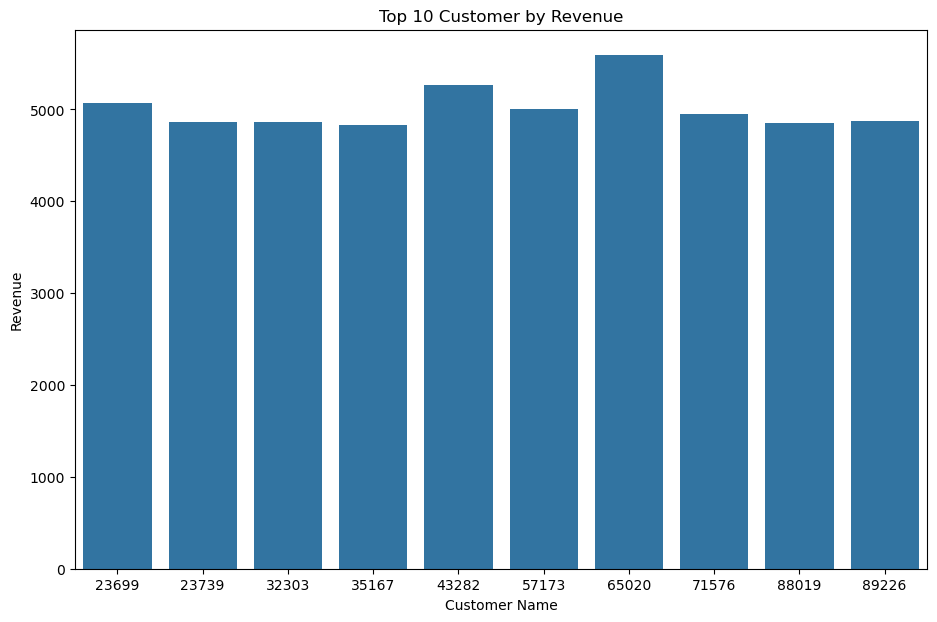

In [40]:
plt.figure(figsize = (11,7))
sns.barplot(x=customer_feq.index,y= customer_feq.values)
plt.title("Top 10 Customer by Revenue")
plt.xlabel("Customer Name")
plt.ylabel("Revenue")
plt.show()

In [41]:
plt.savefig("Customer_by_revenue.png")

<Figure size 640x480 with 0 Axes>

In [42]:
df.to_csv("cleaned_sales_data.csv", index=False)

# Key Insights

1. Transaction amounts show a right distribution, indicating most purchases are small but a few large transactions exist.

2. Monthly revenue trends indicate fluctuations in customer purchasing behavior.

3. Some product categories generate significantly higher revenue, suggesting strong customer demand.

4. A small group of customers contributes a large portion of total revenue.

# Conclusion

This analysis highlights important revenue patterns and customer behavior trends that can help businesses improve marketing strategies and inventory planning.